# Response time by direction on the 0-facts

Distribution of the response time of **correct** answers to `0×n` versus `n×0`, by classroom course age.
Source: A998 fluency test, same population and filters as the other notebooks (`DECISIONS.txt` #1–#11).
Queries: `queries/rt_zero_facts_correct.sql` (one row per response) and `queries/rt_error_by_fact_age.sql`
(used only to apply the ≥ 30 rule, which counts all responses, not just the correct ones).

In [1]:
import re, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis, skew, ttest_rel

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
from paired_stats import holm, median_ci, signed_rank, stars
from plot_style import C_DIR, FONT_BIG, FONT_MED, paint_it_black, set_style

SQL_RT, SQL_CELLS = ROOT / "queries/rt_zero_facts_correct.sql", ROOT / "queries/rt_error_by_fact_age.sql"
PLOTS = ROOT / "analysis" / "plots"; PLOTS.mkdir(exist_ok=True)
C_0N, C_N0 = C_DIR
MIN_N = 30          # DECISIONS #11, per fact x age cell, on ALL responses
RT_LIM = (0, 4)    # y-axis of the violins; display only, no response is dropped (DECISIONS #10)
YEAR = "ES_2025"
set_style()


In [2]:
def _year(path, year):
    return re.sub(r"'[A-Z_0-9-]+'(\s+-- \{YEAR\})", f"'{year}'\\1", path.read_text(encoding="utf-8"))

def load_rt(year):
    cells = cached_query(SQL_CELLS, cache_dir=ROOT / "cache", sql_text=_year(SQL_CELLS, year))
    keep = set(zip(cells.course_age, cells.operation))          # the >= 30 cells (query HAVINGs it)
    df = cached_query(SQL_RT, cache_dir=ROOT / "cache", sql_text=_year(SQL_RT, year))
    df = df[pd.MultiIndex.from_arrays([df.course_age, df.operation]).isin(keep)].copy()
    a, b = df.left_factor, df.right_factor
    df["direction"] = np.where(a.eq(0) & b.eq(0), "0×0", np.where(a.eq(0), "0×n", "n×0"))
    df["n"] = np.where(a.eq(0), b, a)                           # the non-zero operand
    return df

def save(fig, stem):
    fig.savefig(PLOTS / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(PLOTS / f"{stem}.png", dpi=300, bbox_inches="tight")


## Coverage

`0×0` is excluded from the comparison (DECISIONS #15): it belongs to neither direction. Age 8 disappears
on its own — the test administers no 0-facts there, so no `0-fact × age 8` cell clears the ≥ 30 rule.

In [3]:
df = load_rt(YEAR)
pair = df[df.direction.ne("0×0")]

def coverage(d):
    g = d.groupby(["direction", "course_age"])
    out = pd.DataFrame({"facts": g.operation.nunique(), "students": g.student_uuid.nunique(),
                        "responses": g.size(), "median_rt": g.rt_seconds.median().round(2),
                        "p25": g.rt_seconds.quantile(.25).round(2), "p75": g.rt_seconds.quantile(.75).round(2),
                        "p99": g.rt_seconds.quantile(.99).round(2), "max": g.rt_seconds.max().round(1)})
    return out

display(coverage(pair))
display(coverage(df[df.direction.eq("0×0")]).rename_axis(["0×0", "course_age"]))


facts  students  responses  median_rt   p25   p75  \
direction course_age                                                      
0×n       9               9      9942      13761       2.67  2.13  3.60   
          10              9     24700      57413       2.40  1.95  3.20   
          11              9     26160      67092       2.17  1.83  2.81   
          12              9     10625      31962       2.06  1.73  2.66   
          13              9      9980      33306       1.88  1.63  2.37   
          14              9      5112      17610       1.83  1.60  2.23   
          15              9      1722       5052       1.78  1.57  2.13   
n×0       9               9      9987      13716       2.74  2.17  3.75   
          10              9     24506      57133       2.40  1.98  3.21   
          11              9     25850      65507       2.20  1.86  2.85   
          12              9     10417      30682       2.10  1.78  2.70   
          13              9      9849      32279       1.92  1.68  2.40   
          14              9      5003      16929       1.85  1.63  2.25   
          15              9      1728       5083       1.83  1.62  2.18   

                        p99    max  
direction course_age                
0×n       9           20.02  101.7  
          10          19.17  108.9  
          11          17.64  108.1  
          12          16.79   99.5  
          13          15.45  112.6  
          14          15.25   98.4  
          15          14.39   49.7  
n×0       9           20.40   93.6  
          10          19.41  114.3  
          11          18.34   97.8  
          12          16.68  103.7  
          13          15.58  110.2  
          14          14.11  106.6  
          15          14.41  101.8

facts  students  responses  median_rt   p25   p75    p99  \
0×0 course_age                                                             
0×0 9               1      1818       1818       2.30  1.95  3.10  23.74   
    10              1      6621       7160       2.13  1.82  2.77  21.44   
    11              1      7351       8097       1.95  1.70  2.40  18.87   
    12              1      3353       3771       1.85  1.63  2.26  16.75   
    13              1      3442       3934       1.74  1.57  2.05  13.86   
    14              1      1779       2038       1.70  1.53  2.02  14.97   
    15              1       548        615       1.67  1.50  1.95  12.82   

                  max  
0×0 course_age         
0×0 9            52.6  
    10           97.7  
    11          110.5  
    12           53.1  
    13           33.4  
    14           60.1  
    15           72.8

## Is the difference significant?

Responses are nested in students and a student meets both directions in the same test, so the direction
effect is tested **paired**: one median RT per student and direction, then the **Wilcoxon signed-rank test**
on the per-student difference `n×0 − 0×n`. Rank-based rather than parametric: the differences are near-symmetric but extremely heavy-tailed
(a handful of students differ by ±60 s), so a mean-based test is at the mercy of those few. A paired
*t* test is reported alongside as a robustness check — it agrees on the direction but is far weaker,
which is exactly the tail dominance.
Effect size: matched-pairs rank-biserial correlation. The CI of the median difference comes from the order
statistics, which assumes nothing about the shape. Seven ages are tested, so the p values are also reported
**Holm-corrected** family-wise.

In [4]:
def paired_table(d):
    w = (d.groupby(["course_age", "student_uuid", "direction"]).rt_seconds.median()
           .unstack("direction").dropna())
    w["diff"] = w["n×0"] - w["0×n"]
    rows = {age: {**signed_rank(g["diff"].to_numpy()),
                  "med_0xn": g["0×n"].median(), "med_nx0": g["n×0"].median()}
            for age, g in w.groupby("course_age")}
    out = pd.DataFrame(rows).T.rename_axis("course_age")
    out["p_holm"] = holm(out.p.to_numpy())
    out["sig"] = [stars(x) for x in out.p_holm]
    return out[["students", "med_0xn", "med_nx0", "med_diff", "ci_lo", "ci_hi",
                "pct_slower", "r_rb", "p", "p_holm", "sig"]], w

paired, wide = paired_table(pair)
paired.assign(students=paired.students.astype(int)).round(
    {"med_0xn": 2, "med_nx0": 2, "med_diff": 3, "ci_lo": 3, "ci_hi": 3, "pct_slower": 1, "r_rb": 3})


,students,med_0xn,med_nx0,med_diff,ci_lo,ci_hi,pct_slower,r_rb,p,p_holm,sig
course_age,,,,,,,,,,,
9,5061,2.55,2.61,0.059,0.031,0.085,52.6,0.052,1.320506e-03,2.641013e-03,**
10,19721,2.45,2.48,0.025,0.016,0.034,51.3,0.023,5.240928e-03,5.240928e-03,**
11,21658,2.23,2.27,0.036,0.032,0.050,52.8,0.062,3.457772e-15,2.420440e-14,***
12,9232,2.13,2.17,0.048,0.033,0.058,53.7,0.082,7.409722e-12,3.704861e-11,***
13,8968,1.95,1.99,0.042,0.033,0.050,54.6,0.093,3.550032e-14,2.130019e-13,***
14,4587,1.87,1.92,0.033,0.024,0.048,54.4,0.104,1.337378e-09,5.349511e-09,***
15,1508,1.82,1.86,0.039,0.021,0.066,55.6,0.115,1.090992e-04,3.272977e-04,***


In [5]:
# the same test on every student at once, plus the checks behind the choice of test
dif = wide["diff"].to_numpy()
ov = signed_rank(dif)
fmt = lambda p: "< .001" if p < .001 else f"= {p:.3f}"

print(f"Per-student differences: skew {skew(dif):.1f} (near-symmetric), excess kurtosis {kurtosis(dif):.0f}, "
      f"range [{dif.min():.0f}, {dif.max():.0f}] s  ->  rank test, the mean is at the mercy of the tails")
print(f"ALL AGES: n = {ov['students']:,} students, Mdn(n×0 − 0×n) = {1000 * ov['med_diff']:.0f} ms, "
      f"95% CI [{1000 * ov['ci_lo']:.0f}, {1000 * ov['ci_hi']:.0f}], "
      f"{ov['pct_slower']:.1f}% of students slower on n×0")
print(f"          Wilcoxon signed-rank p {fmt(ov['p'])}, r_rb = {ov['r_rb']:.3f} | "
      f"paired t p {fmt(ttest_rel(wide['n×0'], wide['0×n']).pvalue)} (robustness)")
for age, r in paired.iterrows():
    print(f"Age {age:.0f}:   n = {r.students:,.0f}, Mdn 0×n = {r.med_0xn:.2f} s, Mdn n×0 = {r.med_nx0:.2f} s, "
          f"Mdn diff = {1000 * r.med_diff:.0f} ms, 95% CI [{1000 * r.ci_lo:.0f}, {1000 * r.ci_hi:.0f}], "
          f"p {fmt(r.p)}, Holm {fmt(r.p_holm)} {r.sig}, r_rb = {r.r_rb:.3f}")


Per-student differences: skew -0.3 (near-symmetric), excess kurtosis 100, range [-103, 111] s  ->  rank test, the mean is at the mercy of the tails
ALL AGES: n = 70,735 students, Mdn(n×0 − 0×n) = 34 ms, 95% CI [33, 42], 52.9% of students slower on n×0
          Wilcoxon signed-rank p < .001, r_rb = 0.058 | paired t p = 0.002 (robustness)
Age 9:   n = 5,061, Mdn 0×n = 2.55 s, Mdn n×0 = 2.61 s, Mdn diff = 59 ms, 95% CI [31, 85], p = 0.001, Holm = 0.003 **, r_rb = 0.052
Age 10:   n = 19,721, Mdn 0×n = 2.45 s, Mdn n×0 = 2.48 s, Mdn diff = 25 ms, 95% CI [16, 34], p = 0.005, Holm = 0.005 **, r_rb = 0.023
Age 11:   n = 21,658, Mdn 0×n = 2.23 s, Mdn n×0 = 2.27 s, Mdn diff = 36 ms, 95% CI [32, 50], p < .001, Holm < .001 ***, r_rb = 0.062
Age 12:   n = 9,232, Mdn 0×n = 2.13 s, Mdn n×0 = 2.17 s, Mdn diff = 48 ms, 95% CI [33, 58], p < .001, Holm < .001 ***, r_rb = 0.082
Age 13:   n = 8,968, Mdn 0×n = 1.95 s, Mdn n×0 = 1.99 s, Mdn diff = 42 ms, 95% CI [33, 50], p < .001, Holm < .001 ***, r_rb = 0.0

## Figure

**A** — the two distributions, split violin, one pair per age, y-axis 0–15 s. The cut is display only:
every response still enters the kernel, the quartile lines and every number reported here (RT reaches
~110 s, but only 1.7% of responses are above 15 s). The same figure on a log axis, which shows the whole
range including the tail, is saved alongside it as `*_log`.
**B** — the per-student difference the violins are too coarse to show: median of `n×0 − 0×n` with its
95% CI, marked with the Holm-corrected Wilcoxon significance (`***` p < .001, `**` p < .01, `*` p < .05).

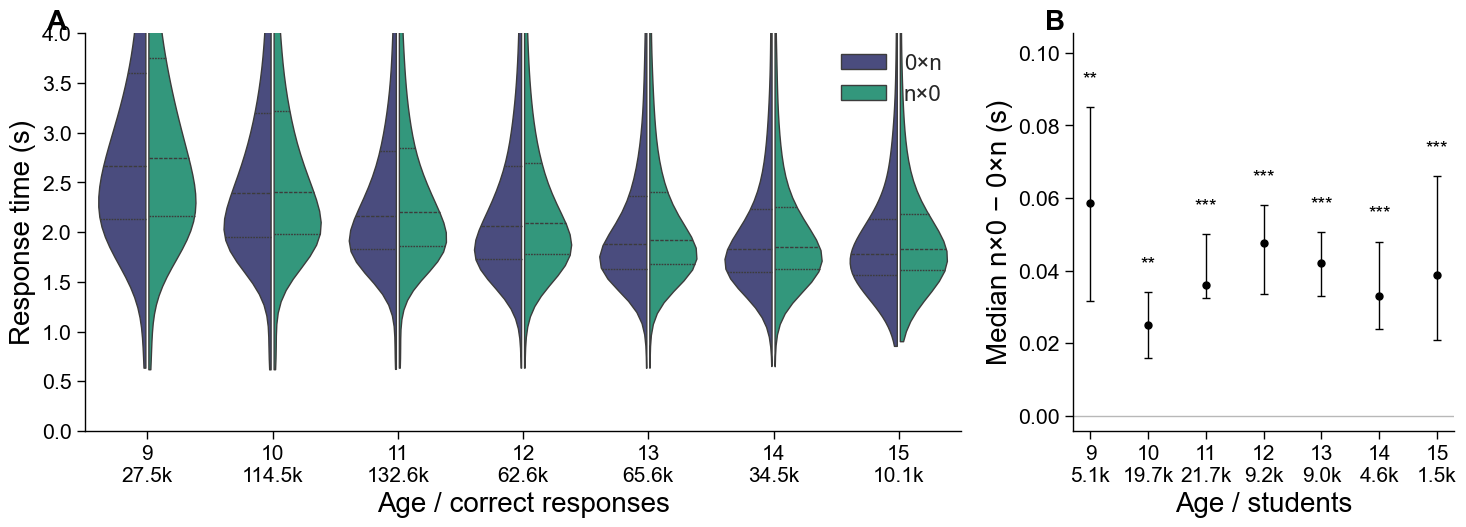

In [6]:
LOG_TICKS = [1, 2, 3, 5, 10, 20, 50, 100]
compact = lambda n: f"{n / 1000:.1f}k" if n >= 1000 else f"{n:.0f}"   # keeps the n row narrow

def rt_figure(d, paired, stem, log=True):
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5.6), gridspec_kw={"width_ratios": [2.3, 1]})
    sns.violinplot(data=d, x="course_age", y="rt_seconds", hue="direction", hue_order=["0×n", "n×0"],
                   split=True, gap=.06, inner="quartile", cut=0, bw_adjust=.55, density_norm="width",
                   gridsize=1000, linewidth=1, palette={"0×n": C_0N, "n×0": C_N0},
                   log_scale=(False, log), ax=ax)
    # gridsize: the KDE grid spans the whole data range (0.6-110 s). At seaborn's default of 100 points
    # that is one point every 1.1 s, so the body of the distribution (1-5 s) is drawn with ~4 points and
    # comes out as a straight-edged triangle. 1000 points = 0.11 s, which is the actual shape.
    if log:
        ax.set_yticks(LOG_TICKS); ax.set_yticklabels(LOG_TICKS); ax.minorticks_off()
    else:
        ax.set_ylim(*RT_LIM)
    n_resp = d.groupby("course_age").size()          # sample size under each pair of violins
    ax.set_xticks(range(len(n_resp)))
    ax.set_xticklabels([f"{a}\n{compact(n)}" for a, n in n_resp.items()])
    ax.tick_params(axis="x", labelsize=FONT_MED - 1)
    ax.set_xlabel("Age / correct responses", fontsize=FONT_BIG)
    ax.set_ylabel("Response time (s)", fontsize=FONT_BIG)
    ax.legend(frameon=False, fontsize=FONT_MED, loc="upper right", title=None)

    ages = paired.index.to_numpy()
    err = np.vstack([paired.med_diff - paired.ci_lo, paired.ci_hi - paired.med_diff])
    ax2.axhline(0, color="#B8B8B8", lw=1, zorder=1)
    ax2.errorbar(ages, paired.med_diff, yerr=err, fmt="o", capsize=3, markersize=5,
                 color="black", ecolor="black", elinewidth=1, zorder=2)
    pad = .06 * (paired.ci_hi.max() - min(0, paired.ci_lo.min()))
    for age, r in paired.iterrows():
        ax2.text(age, r.ci_hi + pad, r.sig, ha="center", va="bottom", fontsize=FONT_MED - 2, color="black")
    ax2.set_ylim(top=paired.ci_hi.max() + 4 * pad)
    ax2.set_xlabel("Age / students", fontsize=FONT_BIG); ax2.set_xticks(ages)
    ax2.set_xticklabels([f"{a:.0f}\n{compact(n)}" for a, n in paired.students.items()])
    ax2.tick_params(axis="x", labelsize=FONT_MED - 1)
    ax2.set_ylabel("Median n×0 − 0×n (s)", fontsize=FONT_BIG)

    for a, letter in [(ax, "A"), (ax2, "B")]:
        a.text(-.02, 1.06, letter, transform=a.transAxes, fontweight="bold", fontsize=FONT_BIG,
               va="top", ha="right", color="black")
        sns.despine(ax=a)
    fig.tight_layout(); paint_it_black([ax, ax2]); save(fig, stem)
    plt.close(fig)          # saved, not shown -- the cell displays the main figure only
    return fig

STEM = f"rt_violin_zero_direction_by_age_{YEAR}"
rt_figure(pair, paired, STEM + "_log", log=True)       # saved to plots/, not displayed
rt_figure(pair, paired, STEM, log=False)               # the figure of the notebook


## Sanity checks

In [7]:
raw = cached_query(SQL_RT, cache_dir=ROOT / "cache", sql_text=_year(SQL_RT, YEAR))
assert df.rt_seconds.notna().all() and df.rt_seconds.gt(0).all()
assert set(df.direction) == {"0×n", "n×0", "0×0"} and pair.n.between(1, 9).all()
assert df.groupby(["course_age", "operation"]).size().min() >= 1
kept = df.groupby("course_age").size()
print(f"{len(df):,} of {len(raw):,} responses kept (>= {MIN_N} rule) | ages {kept.index.min()}-{kept.index.max()}")
print(f"{pair.student_uuid.nunique():,} students, {len(wide):,} student x age pairs with both directions")
print(f"y-axis {RT_LIM[0]}-{RT_LIM[1]} s: {100 * pair.rt_seconds.gt(RT_LIM[1]).mean():.1f}% of responses "
      f"above it (drawn but off-view; the *_log variant shows the full range)")


474,958 of 474,989 responses kept (>= 30 rule) | ages 9-15
104,846 students, 70,735 student x age pairs with both directions
y-axis 0-4 s: 11.9% of responses above it (drawn but off-view; the *_log variant shows the full range)
